# NLA Roundtrip Visualizer

## Load Results

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path("ssd1/results/fv_shot_sweep/20260817_000518")
RUN_DIR = Path("ssd1/results/fv_shot_sweep/20260823_235138")

INTERVENTIONS = [
    "baseline",
    "nla",
    "random_vec",
    "mismatch_cross_task",
    "mismatch_same_task",
    "para_medium",
    "para_heavy",
]
INTERVENTION_LABELS = {
    "baseline": "Baseline (no intervention)",
    "nla": "NLA round-trip",
    "random_vec": "Random vector",
    "mismatch_cross_task": "Mismatched FV (cross-task)",
    "mismatch_same_task": "Mismatched FV (same-task)",
    "para_medium": "Paraphrase round-trip (medium)",
    "para_heavy": "Paraphrase round-trip (heavy)",
}
INTERVENTION_COLORS = {
    "baseline": "#8a8a8a",  # gray
    "nla": "#2a78d6",  # blue
    "random_vec": "#9b59b6",  # purple
    "mismatch_cross_task": "#c0392b",  # red
    "mismatch_same_task": "#e67e22",  # dark orange
    "para_medium": "#eb6834",  # orange
    "para_heavy": "#2ca02c",  # green
}
GRID_COLOR = "#e1e0d9"

csv_paths = sorted(RUN_DIR.glob("fv_shot_sweep_*.csv"))
TASKS = [
    p.stem.removeprefix("fv_shot_sweep_").removesuffix(f"_{RUN_DIR.name}")
    for p in csv_paths
]

sweeps = {
    task: pd.read_csv(path).sort_values("n_shots").reset_index(drop=True)
    for task, path in zip(TASKS, csv_paths)
}

all_n_shots = sorted(pd.concat([df["n_shots"] for df in sweeps.values()]).unique())
print(f"Loaded {len(sweeps)} tasks: {TASKS}")
print(f"Shot counts: {all_n_shots}")
print(f"Interventions: {INTERVENTIONS}")

Loaded 6 tasks: ['antonym', 'capitalize', 'country-capital', 'english-french', 'present-past', 'singular-plural']
Shot counts: [np.int64(1), np.int64(2), np.int64(4)]
Interventions: ['baseline', 'nla', 'random_vec', 'mismatch_cross_task', 'mismatch_same_task', 'para_medium', 'para_heavy']


## All Shots

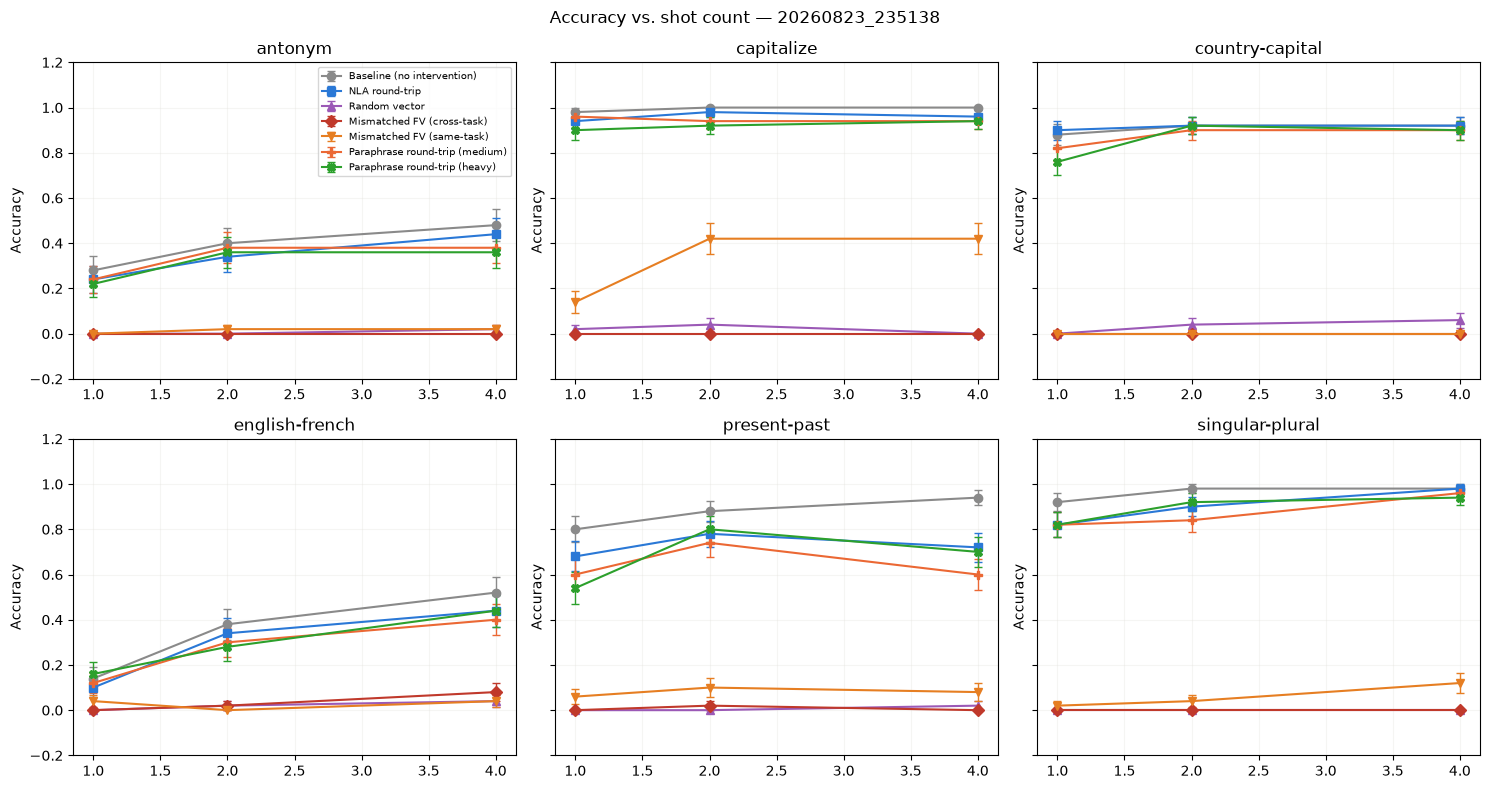

In [ ]:
OUT_DIR = RUN_DIR

MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
CONDITIONS = [
    (f"acc_{interv}", marker, INTERVENTION_LABELS[interv], INTERVENTION_COLORS[interv])
    for interv, marker in zip(INTERVENTIONS, MARKERS)
]


def plot_sweep(results: dict[str, pd.DataFrame], run_id: str, individual_plots=False):
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    if individual_plots:
        for task_name, df in results.items():
            fig, ax = plt.subplots(figsize=(5, 4))
            for col, marker, label, color in CONDITIONS:
                if col not in df.columns:
                    print(
                        f"[warn] {task_name}: missing column {col!r}, skipping that line"
                    )
                    continue
                se_col = col.replace("acc_", "se_", 1)
                yerr = df[se_col] if se_col in df.columns else None
                ax.errorbar(
                    df["n_shots"],
                    df[col],
                    yerr=yerr,
                    marker=marker,
                    label=label,
                    color=color,
                    capsize=3,
                    elinewidth=1,
                    markeredgewidth=1,
                )
            ax.set_xlabel("Number of shots")
            ax.set_ylabel("Accuracy")
            ax.set_ylim(-0.2, 1.2)
            ax.set_title(task_name)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3, color=GRID_COLOR)
            fig.tight_layout()
            fig.savefig(OUT_DIR / f"fv_shot_sweep_{task_name}_{run_id}.png", dpi=150)
            plt.show()

    n_cols = 3
    n_rows = -(-len(TASKS) // n_cols)  # ceil
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True
    )
    for ax, task_name in zip(axes.flat, TASKS):
        if task_name not in results:
            ax.set_title(f"{task_name} (no data)")
            ax.axis("off")
            continue
        df = results[task_name]
        for col, marker, label, color in CONDITIONS:
            if col not in df.columns:
                continue
            se_col = col.replace("acc_", "se_", 1)
            yerr = df[se_col] if se_col in df.columns else None
            ax.errorbar(
                df["n_shots"],
                df[col],
                yerr=yerr,
                marker=marker,
                label=label,
                color=color,
                capsize=3,
                elinewidth=1,
                markeredgewidth=1,
            )
        ax.set_title(task_name)
        ax.set_xlabel("Number of shots")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(-0.2, 1.2)
        ax.grid(alpha=0.3, color=GRID_COLOR)

    for ax in axes.flat[len(TASKS) :]:
        ax.set_visible(False)

    handled_axes = [ax for ax in axes.flat if ax.lines]
    if handled_axes:
        handled_axes[0].legend(fontsize=7)
    fig.suptitle(f"Accuracy vs. shot count — {run_id}")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"fv_shot_sweep_all_tasks_{run_id}.png", dpi=150)
    plt.show()


plot_sweep(sweeps, RUN_DIR.name, individual_plots=False)

## Single Shot

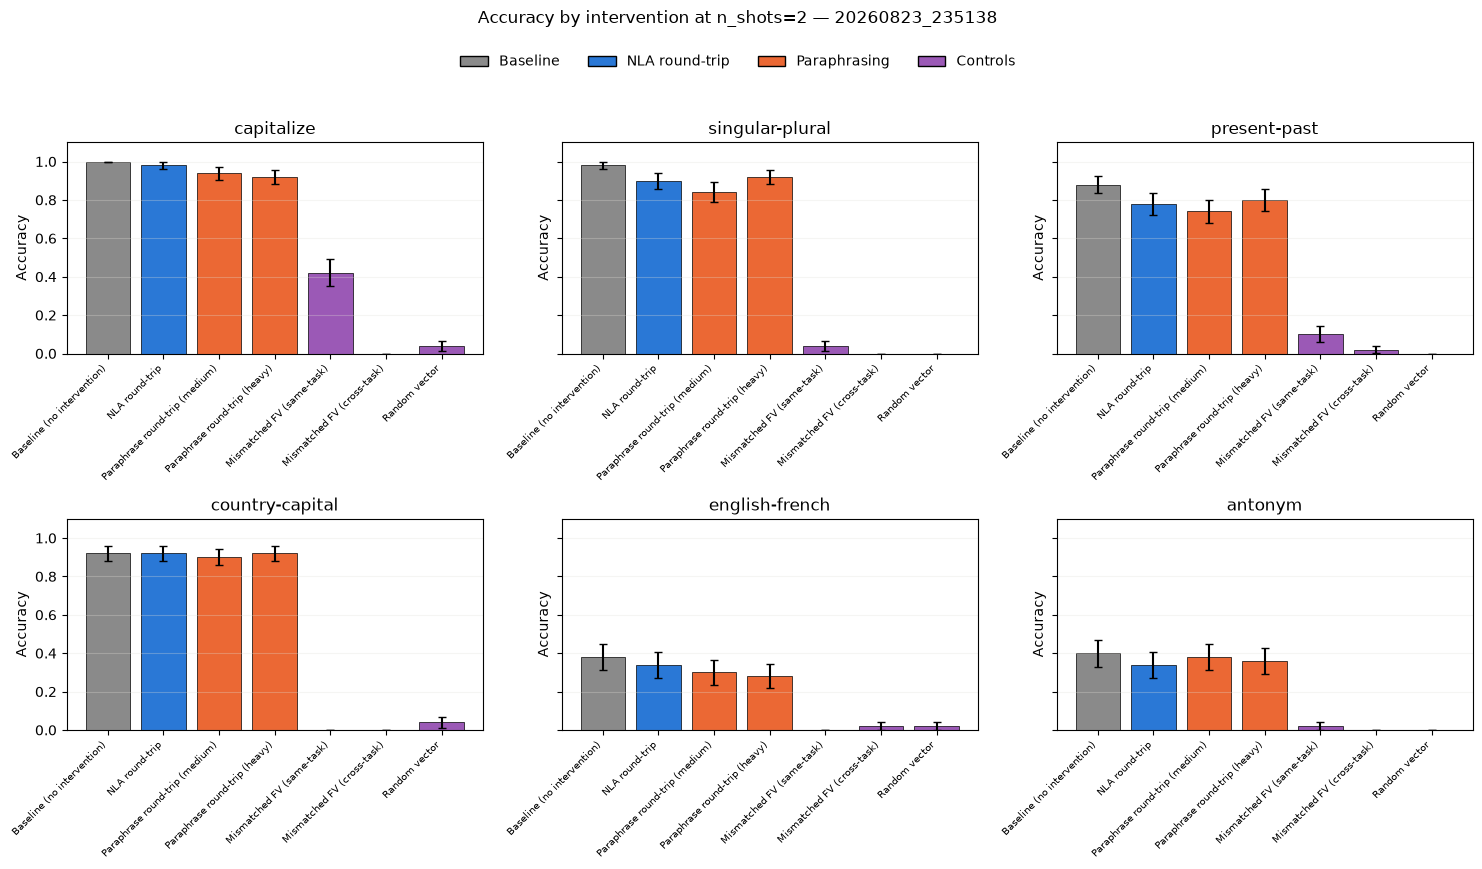

In [8]:
from matplotlib.patches import Patch

N_SHOTS_TO_PLOT = 2
assert N_SHOTS_TO_PLOT in all_n_shots, f"{N_SHOTS_TO_PLOT} not in {all_n_shots}"

# Bar order/colors for this plot only: baseline, roundtrip, then the
# paraphrase group (medium/heavy, same color), then the controls group
# (same-task, cross-task, random vector, same color).
BAR_ORDER = [
    "baseline",
    "nla",
    "para_medium",
    "para_heavy",
    "mismatch_same_task",
    "mismatch_cross_task",
    "random_vec",
]
BAR_COLORS = {
    "baseline": "#8a8a8a",  # gray
    "nla": "#2a78d6",  # blue
    "para_medium": "#eb6834",  # orange -- paraphrase group
    "para_heavy": "#eb6834",  # orange -- paraphrase group
    "mismatch_same_task": "#9b59b6",  # purple -- controls group
    "mismatch_cross_task": "#9b59b6",  # purple -- controls group
    "random_vec": "#9b59b6",  # purple -- controls group
}
GROUP_LEGEND_HANDLES = [
    Patch(facecolor=BAR_COLORS["baseline"], edgecolor="black", label="Baseline"),
    Patch(facecolor=BAR_COLORS["nla"], edgecolor="black", label="NLA round-trip"),
    Patch(facecolor=BAR_COLORS["para_medium"], edgecolor="black", label="Paraphrasing"),
    Patch(facecolor=BAR_COLORS["random_vec"], edgecolor="black", label="Controls"),
]

# Task plots ordered by difficulty (easy to hard), rather than alphabetically.
TASK_DIFFICULTY_ORDER = [
    "capitalize",
    "singular-plural",
    "present-past",
    "country-capital",
    "english-french",
    "antonym",
]

x = range(len(BAR_ORDER))
bar_colors = [BAR_COLORS[interv] for interv in BAR_ORDER]
bar_labels = [INTERVENTION_LABELS[interv] for interv in BAR_ORDER]

n_cols = 3
n_rows = -(-len(TASK_DIFFICULTY_ORDER) // n_cols)  # ceil
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)

for ax, task_name in zip(axes.flat, TASK_DIFFICULTY_ORDER):
    df = sweeps[task_name]
    row = df[df["n_shots"] == N_SHOTS_TO_PLOT]
    if row.empty:
        ax.set_title(f"{task_name} (no data)")
        ax.axis("off")
        continue
    row = row.iloc[0]

    values, errs = [], []
    for interv in BAR_ORDER:
        col = f"acc_{interv}"
        se_col = f"se_{interv}"
        values.append(row[col] if col in df.columns else float("nan"))
        errs.append(row[se_col] if se_col in df.columns else 0.0)

    ax.bar(
        x,
        values,
        yerr=errs,
        color=bar_colors,
        capsize=3,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(bar_labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(task_name)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3, color=GRID_COLOR, axis="y")

for ax in axes.flat[len(TASK_DIFFICULTY_ORDER) :]:
    ax.set_visible(False)

fig.legend(
    handles=GROUP_LEGEND_HANDLES,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
)
fig.suptitle(
    f"Accuracy by intervention at n_shots={N_SHOTS_TO_PLOT} — {RUN_DIR.name}", y=1.08
)
fig.tight_layout()
fig.savefig(OUT_DIR / f"fv_shot_bar_n{N_SHOTS_TO_PLOT}_{RUN_DIR.name}.png", dpi=150)
plt.show()

The figure above fixing the number of shots to 2 and orders the task by difficulty, where capitalize is the easiest and antonym is most difficult. The colors correspond to the type of intervention. In summary, as task difficulty increases, the accuracies degrade, as expected. NLA round trip has no significant effect on model accuracy. Paraphrasing degrades accuracy but only significant for easy tasks (top row). The controls are not able to complete the task with the one exception of "capitalize" for the same-task mismatched function vector (FV) (Tood et al.). An FV is a vector extracted from a handful of in-context demonstrations (the shots) and is injected into the residual stream. Capitalization is an easy task and the function vector from one task transfers from one query-answer pair to different query answer pair.

The results show that accuracy does indeed vary across the different levels of NLA intervention. Both heavy and medium paraphrasing tend to fall below the baseline, and the standard errors confirm that this drop is significant for the easier tasks (top-row). However for more difficult task, the error bars between paraphrasing and the baseline overlap, indicating insignificance. For difficult tasks, paraphrasing doesn't have an effect because model performance is already poor. 

The NLA round-trip, by contrast, does not produce a significant drop in accuracy, for all tasks. Task-level patterns vary as well: for “singular-plural”, the gap between interventions stays small even at n-shots = 6, with paraphrase (medium) performing just as well as the baseline. For “country-capital”, however, the interventions separate clearly and in the order predicted by our initial hypothesis, with accuracy decreasing as intervention strength increases.



## Out-of-Task Answer Change

## Mistake Attribution

In [10]:
NLA_MISTAKE_DIR = Path(
    sorted(Path("ssd1/results/nla_mistake_attribution").iterdir())[-1]
)

mistake_csv_paths = sorted(NLA_MISTAKE_DIR.glob("nla_mistake_attribution_*.csv"))
mistake_results = {
    p.stem.removeprefix("nla_mistake_attribution_")
    .removesuffix(f"_{NLA_MISTAKE_DIR.name}"): pd.read_csv(p)
    .sort_values("n_shots")
    .reset_index(drop=True)
    for p in mistake_csv_paths
}

print(f"Run: {NLA_MISTAKE_DIR.name}")
print(f"Loaded {len(mistake_results)} tasks: {list(mistake_results.keys())}")

Run: 20260825_044756
Loaded 6 tasks: ['antonym', 'capitalize', 'country-capital', 'english-french', 'present-past', 'singular-plural']


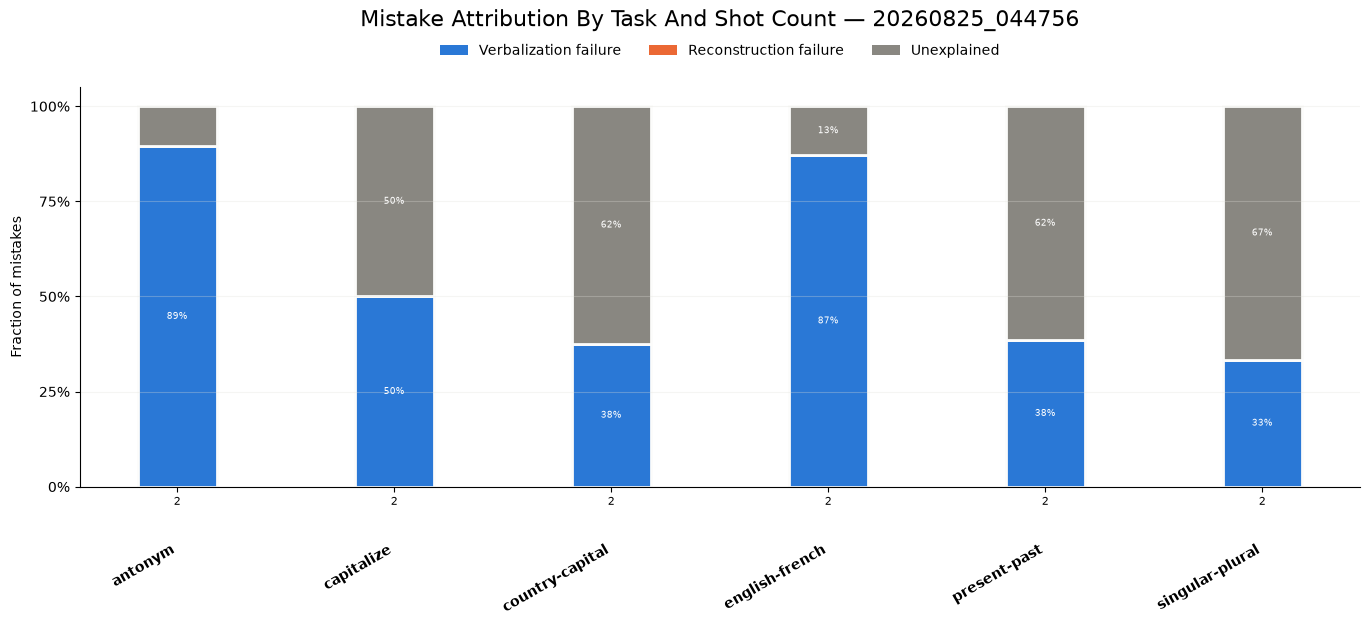

In [20]:
from matplotlib.patches import Patch

OUT_DIR = NLA_MISTAKE_DIR

FAILURE_TYPES = [
    "verbalization_failure_rate",
    "reconstruction_failure_rate",
    "unexplained_rate",
]
FAILURE_LABELS = {
    "verbalization_failure_rate": "Verbalization failure",
    "reconstruction_failure_rate": "Reconstruction failure",
    "unexplained_rate": "Unexplained",
}
FAILURE_COLORS = {
    "verbalization_failure_rate": "#2a78d6",  # blue
    "reconstruction_failure_rate": "#eb6834",  # orange
    "unexplained_rate": "#898781",  # neutral gray -- residual/uncategorized bucket
}
SURFACE_COLOR = "#fcfcfb"
BAR_WIDTH = 0.8
GROUP_GAP = 1.2  # extra x-space (in bar-slot units) between task groups


def plot_sweep(results: dict[str, pd.DataFrame], run_id: str):
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    present_tasks = [t for t in TASKS if t in results]
    shot_counts = sorted({n for df in results.values() for n in df["n_shots"]})
    group_width = len(shot_counts) + GROUP_GAP

    fig, ax = plt.subplots(figsize=(max(10, 2.3 * len(present_tasks)), 6.5))

    xticks, xticklabels = [], []
    group_centers = []
    for gi, task_name in enumerate(present_tasks):
        df = results[task_name].set_index("n_shots")
        group_start = gi * group_width
        group_positions = []
        for si, n_shots in enumerate(shot_counts):
            x = group_start + si
            group_positions.append(x)
            if n_shots not in df.index:
                continue
            row = df.loc[n_shots]
            bottom = 0.0
            for col in FAILURE_TYPES:
                if col not in df.columns:
                    continue
                v = row[col]
                ax.bar(
                    x,
                    v,
                    bottom=bottom,
                    width=BAR_WIDTH,
                    color=FAILURE_COLORS[col],
                    edgecolor=SURFACE_COLOR,
                    linewidth=2,
                )
                if v >= 0.12:
                    ax.text(
                        x,
                        bottom + v / 2,
                        f"{v:.0%}",
                        ha="center",
                        va="center",
                        fontsize=6.5,
                        color="white",
                    )
                bottom += v
            xticks.append(x)
            xticklabels.append(str(n_shots))
        group_centers.append(sum(group_positions) / len(group_positions))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=8)
    # ax.set_xlabel("Number of shots", labelpad=48)
    for center, task_name in zip(group_centers, present_tasks):
        ax.text(
            center,
            -0.14,
            task_name,
            rotation=30,
            ha="right",
            va="top",
            transform=ax.get_xaxis_transform(),
            fontsize=10,
            fontweight="bold",
        )

    ax.set_ylabel("Fraction of mistakes")
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.grid(alpha=0.3, color=GRID_COLOR, axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=FAILURE_COLORS[col], label=FAILURE_LABELS[col])
        for col in FAILURE_TYPES
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.14),
    )
    ax.set_title(
        f"Mistake attribution by task and shot count — {run_id}".title(),
        pad=44,
        fontsize=16,
    )
    fig.tight_layout()
    fig.savefig(
        OUT_DIR / f"nla_mistake_attribution_combined_{run_id}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


plot_sweep(mistake_results, NLA_MISTAKE_DIR.name)

## Task Switching

Found 3 task-switch experiments: ['capitalize_allcaps', 'tense', 'en_fr_es']


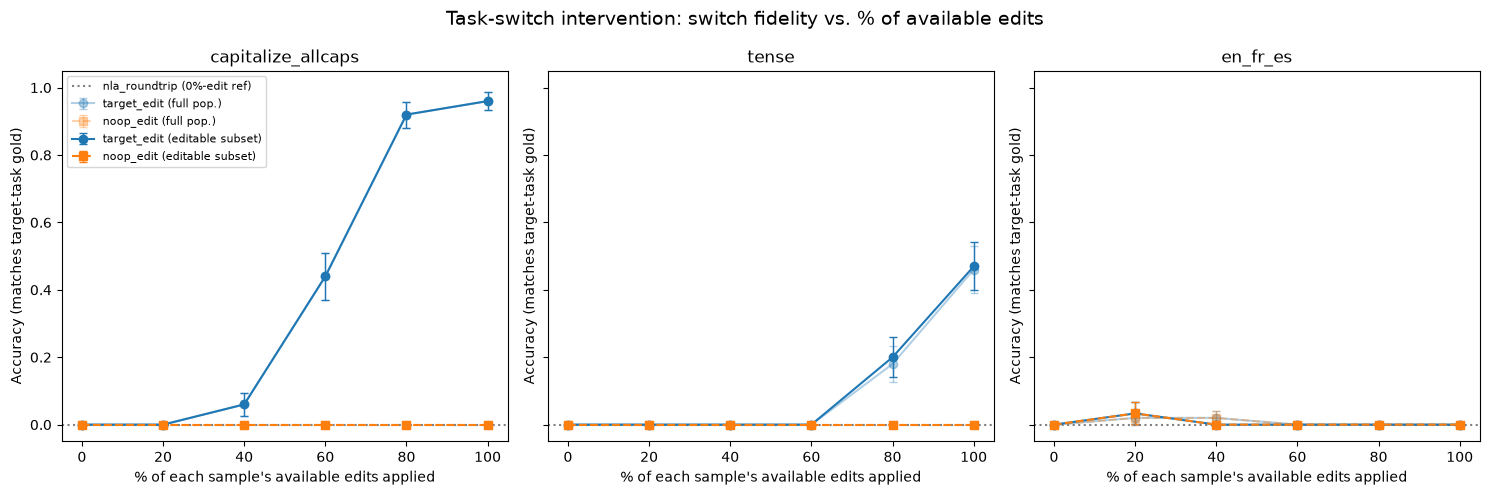

In [6]:
import json

TASK_SWITCH_DIR = Path("ssd1/results/task_switching")

TASK_SWITCH_ORDER = ["capitalize_allcaps", "tense", "en_fr_es"]


def discover_task_switch_tasks() -> list[str]:
    found = {p.parent.name for p in TASK_SWITCH_DIR.glob("*/results.json")}
    ordered = [t for t in TASK_SWITCH_ORDER if t in found]
    ordered += sorted(found - set(TASK_SWITCH_ORDER))
    return ordered


def plot_task_switch_sweeps(task_names: list[str]):
    errbar_kwargs = dict(capsize=3, elinewidth=1, markeredgewidth=1)

    fig, axes = plt.subplots(
        1, len(task_names), figsize=(5 * len(task_names), 5), sharey=True
    )
    if len(task_names) == 1:
        axes = [axes]

    for ax, task_name in zip(axes, task_names):
        task_dir = TASK_SWITCH_DIR / task_name
        with open(task_dir / "results.json") as f:
            results = json.load(f)

        results = sorted(results, key=lambda r: r["pct_edits_requested"])

        x = [r["pct_edits_requested"] for r in results]
        target_acc = [r["acc_target_edit"] for r in results]
        se_target_acc = [r["se_target_edit"] for r in results]
        noop_acc = [r["acc_noop_edit"] for r in results]
        se_noop_acc = [r["se_noop_edit"] for r in results]
        nla_baseline = results[0]["acc_nla_target"]

        # Editable-subset lines: excludes samples with max_available==0, where edit
        # and noop are forced identical and would otherwise dilute the visible gap.
        # .get(...) with a None check keeps this plotting fine against older cached
        # results.json files written before this field existed.
        x_ed, target_acc_ed, se_target_acc_ed = [], [], []
        noop_acc_ed, se_noop_acc_ed = [], []
        for r in results:
            if r.get("acc_target_edit_editable") is not None:
                x_ed.append(r["pct_edits_requested"])
                target_acc_ed.append(r["acc_target_edit_editable"])
                se_target_acc_ed.append(r["se_target_edit_editable"])
                noop_acc_ed.append(r["acc_noop_edit_editable"])
                se_noop_acc_ed.append(r["se_noop_edit_editable"])

        ax.errorbar(
            x,
            target_acc,
            yerr=se_target_acc,
            marker="o",
            label="target_edit (full pop.)",
            color="C0",
            alpha=0.35,
            **errbar_kwargs,
        )
        ax.errorbar(
            x,
            noop_acc,
            yerr=se_noop_acc,
            marker="s",
            label="noop_edit (full pop.)",
            color="C1",
            linestyle="--",
            alpha=0.35,
            **errbar_kwargs,
        )
        if x_ed:
            ax.errorbar(
                x_ed,
                target_acc_ed,
                yerr=se_target_acc_ed,
                marker="o",
                label="target_edit (editable subset)",
                color="C0",
                **errbar_kwargs,
            )
            ax.errorbar(
                x_ed,
                noop_acc_ed,
                yerr=se_noop_acc_ed,
                marker="s",
                linestyle="--",
                label="noop_edit (editable subset)",
                color="C1",
                **errbar_kwargs,
            )
        ax.axhline(
            nla_baseline,
            color="gray",
            linestyle=":",
            label="nla_roundtrip (0%-edit ref)",
        )
        ax.set_xlabel("% of each sample's available edits applied")
        ax.set_ylabel("Accuracy (matches target-task gold)")
        ax.set_title(task_name)
        ax.set_ylim(-0.05, 1.05)

    axes[0].legend(fontsize=8)
    fig.suptitle(
        "Task-switch intervention: switch fidelity vs. % of available edits",
        fontsize=14,
    )
    fig.tight_layout()
    fig.savefig(TASK_SWITCH_DIR / "task_switch_accuracy_sweep.png", dpi=150)
    plt.show()


task_switch_tasks = discover_task_switch_tasks()
print(f"Found {len(task_switch_tasks)} task-switch experiments: {task_switch_tasks}")
plot_task_switch_sweeps(task_switch_tasks)